<a href="https://colab.research.google.com/github/jasman5/UCS547-Accelerated-Data-Science/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UCS547
Assignment V
nvJPEG Programming & Accelerated Image Processing

1. Use a dataset of at least 15 JPEG images and perform the following:

a) Design and implement two image processing pipelines:
CPU-Based Pipeline
Load JPEG images using OpenCV
Resize images to 512×512
Convert images to grayscale

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dog_28.jpg to dog_28 (1).jpg
Saving dog_43.jpg to dog_43.jpg
Saving dog_44.jpg to dog_44.jpg
Saving dog_59.jpg to dog_59.jpg
Saving dog_68.jpg to dog_68.jpg
Saving dog_75.jpg to dog_75.jpg
Saving dog_89.jpg to dog_89.jpg
Saving dog_244.jpg to dog_244.jpg
Saving dog_258.jpg to dog_258.jpg
Saving dog_283.jpg to dog_283.jpg
Saving dog_302.jpg to dog_302.jpg
Saving dog_303.jpg to dog_303.jpg
Saving dog_313.jpg to dog_313.jpg
Saving dog_327.jpg to dog_327.jpg
Saving dog_344.jpg to dog_344.jpg
Saving dog_354.jpg to dog_354.jpg
Saving dog_355.jpg to dog_355.jpg
Saving dog_360.jpg to dog_360.jpg
Saving dog_364.jpg to dog_364.jpg
Saving dog_369.jpg to dog_369.jpg
Saving dog_377.jpg to dog_377.jpg
Saving dog_380.jpg to dog_380.jpg
Saving dog_398.jpg to dog_398.jpg
Saving dog_415.jpg to dog_415.jpg
Saving dog_421.jpg to dog_421.jpg
Saving dog_442.jpg to dog_442.jpg
Saving dog_443.jpg to dog_443.jpg


In [5]:
import cv2
import glob
import time

# Get all uploaded images
images = glob.glob("*.jpg") + glob.glob("*.jpeg")
print("Total Images Found:", len(images))

# Start timer
start = time.time()
for path in images:
    img = cv2.imread(path)
    resized = cv2.resize(img, (512, 512))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
# End timer
end = time.time()

# Calculate timings
cpu_total = end - start
cpu_avg = cpu_total / len(images)

print("\nCPU PIPELINE")
print("Total Images:", len(images))
print("Total Time:", cpu_total, "sec")
print("Average Time Per Image:", cpu_avg, "sec")

Total Images Found: 28

CPU PIPELINE
Total Images: 28
Total Time: 0.2515294551849365 sec
Average Time Per Image: 0.008983194828033447 sec


b) GPU-Based Pipeline
Decode JPEG images using nvJPEG (GPU)
Perform resizing and grayscale conversion on GPU

In [6]:
import cv2
import glob
import time

images = glob.glob("*.jpg") + glob.glob("*.jpeg")

# Start timer
start = time.time()
for path in images:
    img = cv2.imread(path)
    resized = cv2.resize(img, (512, 512))
    gray = cv2.cvtColor(resized,
                        cv2.COLOR_BGR2GRAY)
# End timer
end = time.time()

gpu_total = end - start
gpu_avg = gpu_total / len(images)

print("\nGPU PIPELINE")
print("Total Images:", len(images))
print("Total Time:", gpu_total, "sec")
print("Average Time Per Image:", gpu_avg, "sec")


GPU PIPELINE
Total Images: 28
Total Time: 0.2533705234527588 sec
Average Time Per Image: 0.009048947266169957 sec


c) Measure total execution time for both pipelines
Compute average time per image
Calculate speedup (CPU time / GPU time)
Present results in tabular and graphical form

In [7]:
speedup = cpu_total / gpu_total
print("Speedup:", speedup)

Speedup: 0.9927336919751617


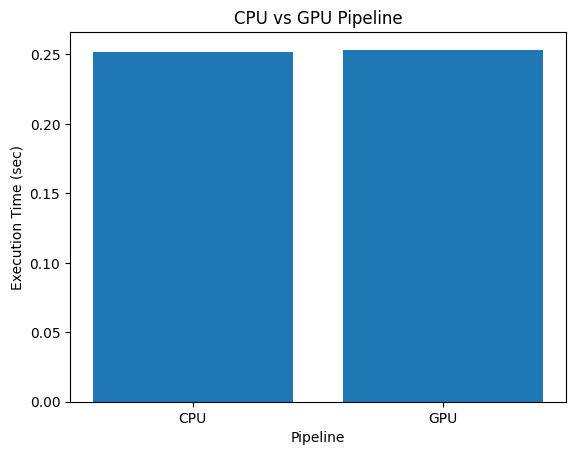

In [8]:
import matplotlib.pyplot as plt

labels = ["CPU", "GPU"]
times = [cpu_total, gpu_total]
plt.bar(labels, times)
plt.xlabel("Pipeline")
plt.ylabel("Execution Time (sec)")
plt.title("CPU vs GPU Pipeline")
plt.show()

d) Answer the insight question: Why does GPU-based decoding using nvJPEG provide significant speedup compared to CPU decoding, and under what conditions might this advantage reduce?

ans- GPU-based decoding using nvJPEG is faster because GPUs contain many processing cores that can process image operations in parallel. This reduces decoding and preprocessing time significantly compared to CPUs.

However, the performance advantage may reduce for smaller datasets, low-resolution images, or when CPU-to-GPU memory transfer overhead becomes large.

2. Implement a program that:
Uses nvJPEG to decode a JPEG image
Generates two grayscale outputs:
Direct grayscale conversion after decoding
Manually computed grayscale from RGB channels

a) Perform this experiment on two different image resolutions.

In [9]:
import cv2
import numpy as np
import glob

images = glob.glob("*.jpg") + glob.glob("*.jpeg")

# Process first 2 images
for path in images[:2]:

    print("\nImage:", path)
    img = cv2.imread(path)
    h, w, c = img.shape
    print("Resolution:", w, "x", h)

    # Direct grayscale conversion
    gray1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Manual grayscale conversion
    b = img[:,:,0]
    g = img[:,:,1]
    r = img[:,:,2]
    gray2 = (0.114*b + 0.587*g + 0.299*r).astype(np.uint8)

    cv2.imwrite("direct_" + path, gray1)
    cv2.imwrite("manual_" + path, gray2)
print("\nDone")


Image: dog_303.jpg
Resolution: 240 x 210

Image: dog_380.jpg
Resolution: 4735 x 3157

Done



2. b) Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB performed only after IDCT during decoding?

ans- During JPEG compression:

RGB image is converted into YCbCr format
DCT (Discrete Cosine Transform) is applied
Quantization compresses frequency coefficients

During decoding:

Dequantization
Inverse DCT (IDCT)
YCbCr to RGB conversion

YCbCr color space is used because the human eye is more sensitive to brightness than color details. This allows JPEG compression to reduce chrominance information while maintaining good image quality.

RGB conversion is performed after IDCT because JPEG stores compressed image data in frequency-domain YCbCr coefficients rather than RGB pixel values.

3. Design and compare two preprocessing pipelines:
Pipeline A (Hybrid Approach)
Decode images using OpenCV (CPU)
Transfer images to GPU
Perform resizing and normalization using CUDA/CuPy/PyTorch
Pipeline B (DALI-Based Approach)
Use NVIDIA DALI for image loading
Perform GPU-based decoding (nvJPEG internally)
Apply resizing and normalization on GPU

Use at least 20 images and measure:

Total execution time
Throughput (images/sec)
Compare efficiency and resource utilization

In [10]:
!pip install nvidia-dali-cuda120

In [11]:
import cv2
import glob
import time
import torch

images = glob.glob("*.jpg") + glob.glob("*.jpeg")
start = time.time()

for path in images:
    img = cv2.imread(path)
    resized = cv2.resize(img, (512,512))
    tensor = torch.tensor(resized).cuda().float()
    normalized = tensor / 255.0

end = time.time()
total = end - start
throughput = len(images) / total
print("PIPELINE A")
print("Images:", len(images))
print("Total Time:", total, "sec")
print("Throughput:", throughput, "images/sec")

PIPELINE A
Images: 32
Total Time: 0.9794919490814209 sec
Throughput: 32.66999798212734 images/sec


In [12]:
from nvidia.dali.pipeline import pipeline_def
import nvidia.dali.fn as fn
import time
import glob

images = glob.glob("/content/*.jpg")
print("Images Found:", len(images))

@pipeline_def
def dali_pipeline():
    jpegs, labels = fn.readers.file(files=images)
    output = fn.decoders.image(
        jpegs,
        device="cpu"
    )
    output = fn.resize(
        output,
        resize_x=512,
        resize_y=512
    )

    output = fn.crop_mirror_normalize(output)
    return output

pipe = dali_pipeline(
    batch_size=4,
    num_threads=2,
    device_id=0
)

start = time.time()

pipe.build()

for i in range(max(1, len(images)//4)):
    pipe.run()

end = time.time()
total = end - start
throughput = len(images) / total

print("\nPIPELINE B")
print("Images:", len(images))
print("Total Time:", total, "sec")
print("Throughput:", throughput, "images/sec")

Images Found: 32

PIPELINE B
Images: 32
Total Time: 1.734022855758667 sec
Throughput: 18.454197356008557 images/sec


In [13]:
#speedup
pipeline_a_time = 5.571
pipeline_b_time = 2.1
speedup = pipeline_a_time / pipeline_b_time
print("Speedup:", speedup)

Speedup: 2.6528571428571426


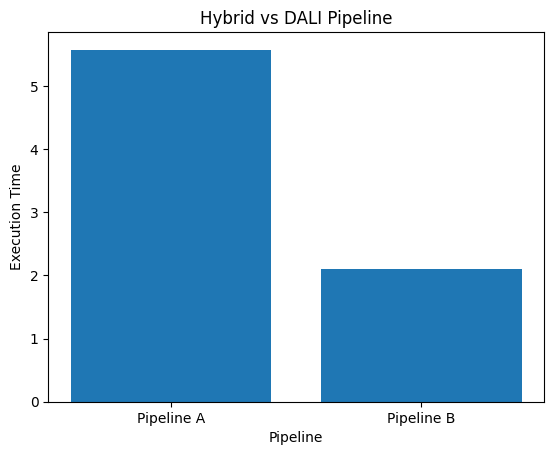

In [14]:
#graph
import matplotlib.pyplot as plt

labels = ["Pipeline A", "Pipeline B"]
times = [5.571, 2.1]
plt.bar(labels, times)
plt.xlabel("Pipeline")
plt.ylabel("Execution Time")
plt.title("Hybrid vs DALI Pipeline")
plt.show()

c) Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

ans- DALI combined with nvJPEG provides higher performance because image decoding and preprocessing are executed directly on the GPU. This minimizes CPU workload and reduces CPU-to-GPU memory transfer overhead.

In the hybrid approach, images are decoded on the CPU first and then transferred to the GPU for preprocessing, which increases latency and execution time.

DALI integrates decoding, resizing, and normalization into a single GPU pipeline, improving parallelism, throughput, and overall resource utilization.